# Latent Stochastic Interpolant for Frame Prediction

Stochastic interpolant drift in VAE latent space.

Trains a conditional drift with an Euler–Maruyama sampler; objective is regression to the interpolant drift target.

The model consists of:
1. A VAE encoder/decoder to compress movies to/from latent space
2. A conditional drift model in latent space
3. A U-Net predicting drift conditioned on the current frame latent


In [1]:
import os
import subprocess
import sys
from pathlib import Path

GITHUB_REPO_URL = "https://github.com/jordanshivers/generative-video-forecasting.git"
REPO_DIRNAME = "generative-video-forecasting"
INSTALL_REQUIREMENTS = True
RETRAIN = False

_current = Path.cwd().resolve()
REPO_ROOT = None
for _candidate in [_current, *_current.parents]:
    if (_candidate / "requirements.txt").exists() and (
        _candidate / "src" / "video_forecasting"
    ).is_dir():
        REPO_ROOT = _candidate
        break

if REPO_ROOT is None:
    _in_colab = "COLAB_GPU" in os.environ or "COLAB_RELEASE_TAG" in os.environ
    if _in_colab:
        _target = Path("/content") / REPO_DIRNAME
        if not _target.exists():
            subprocess.check_call(["git", "clone", GITHUB_REPO_URL, str(_target)])
        for _candidate in [_target, *_target.parents]:
            if (_candidate / "requirements.txt").exists() and (
                _candidate / "src" / "video_forecasting"
            ).is_dir():
                REPO_ROOT = _candidate
                break
    if REPO_ROOT is None:
        raise FileNotFoundError(
            f"Could not find repo root from {_current}. Run locally from the repo root/notebooks "
            "or set GITHUB_REPO_URL for standalone Colab execution."
        )

SRC_ROOT = REPO_ROOT / "src"
if str(SRC_ROOT) not in sys.path:
    sys.path.insert(0, str(SRC_ROOT))

if INSTALL_REQUIREMENTS:
    subprocess.check_call(
        [
            sys.executable,
            "-m",
            "pip",
            "install",
            "-r",
            str(REPO_ROOT / "requirements.txt"),
        ]
    )

from video_forecasting.runtime import get_data_dir, get_output_dir

DATA_DIR = get_data_dir(REPO_ROOT)
OUTPUT_DIR = get_output_dir("train_elastic_disks_latent_stochastic_interpolant", REPO_ROOT)
print(f"Repo root: {REPO_ROOT}")
print(f"Data dir: {DATA_DIR}")
print(f"Output dir: {OUTPUT_DIR}")


Repo root: /content/generative-video-forecasting
Data dir: /content/generative-video-forecasting/data
Output dir: /content/generative-video-forecasting/outputs/train_elastic_disks_latent_stochastic_interpolant


In [2]:
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, ConcatDataset

from pathlib import Path
from typing import List, Tuple, Optional
import matplotlib.pyplot as plt
from tqdm import tqdm
import imageio
import math
import bisect
import warnings

warnings.filterwarnings("ignore")
from video_forecasting.runtime import get_device, set_seed
from video_forecasting.presets import batch_size_for_device, get_preset

set_seed(42)
device = get_device(prefer_mps=True)
print(f"PyTorch version: {torch.__version__}")
print(f"Selected device: {device}")


PyTorch version: 2.10.0+cu128
Selected device: cuda


In [3]:
from video_forecasting.datasets.elastic_disks import ElasticDisksDataset
from video_forecasting.models.vae import SpatialVAE as VAE
from video_forecasting.models.stochastic_interpolants import (
    StochasticInterpolantUtils,
    build_stochastic_interpolant_unet,
)
from video_forecasting.training import (
    ContextFramePredictionDataset,
    FrameOnlyDataset,
    count_parameters,
    evaluate_stochastic_interpolant,
    evaluate_vae,
    train_stochastic_interpolant_epoch,
    train_vae_epoch,
)
from video_forecasting.visualization import (
    display_video,
    generate_stochastic_interpolant_rollout_movie as generate_rollout_movie,
    save_reconstruction_frame,
    set_output_dir,
    visualize_stochastic_interpolant_predictions as visualize_predictions,
    visualize_vae_reconstructions,
)

set_output_dir(OUTPUT_DIR)


PosixPath('/content/generative-video-forecasting/outputs/train_elastic_disks_latent_stochastic_interpolant')

## Load Elastic Disks Data

Load Elastic Disks datasets with train/test splits.

In [4]:
print("Loading Elastic Disks datasets...")
dataset_cfg = get_preset("elastic_disks")
num_sequences = dataset_cfg["num_sequences"]
max_sequences = dataset_cfg["max_sequences"]
sequence_length = dataset_cfg["sequence_length"]
frame_separation = dataset_cfg["frame_separation"]

train_dataset = ElasticDisksDataset(
    root=str(DATA_DIR),
    train=True,
    num_sequences=num_sequences,
    sequence_length=sequence_length,
    image_size=dataset_cfg["image_size"],
    num_particles=dataset_cfg["num_particles"],
    boundary="reflecting",
    render_mode=dataset_cfg["render_mode"],
    normalize=True,
    frame_separation=frame_separation,
    seed=42,
    max_sequences=max_sequences,
)

test_dataset = ElasticDisksDataset(
    root=str(DATA_DIR),
    train=False,
    num_sequences=num_sequences,
    sequence_length=sequence_length,
    image_size=dataset_cfg["image_size"],
    num_particles=dataset_cfg["num_particles"],
    boundary="reflecting",
    render_mode=dataset_cfg["render_mode"],
    normalize=True,
    frame_separation=frame_separation,
    seed=42,
    max_sequences=max_sequences,
)

print("Elastic Disks split:")
print(f"  Train: {len(train_dataset.sequences)} sequences")
print(f"  Test: {len(test_dataset.sequences)} sequences")
print(f"Train samples: {len(train_dataset)}; test samples: {len(test_dataset)}")


Loading Elastic Disks datasets...

Dataset initialized:
  Dataset: elastic_disks
  Split: train
  Total sequences: 2000
  Boundary: reflecting
  Render mode: hard
  Particles: 6
  Frame separation: 1
  Total pairs: 62000
  Image size: 64x64
  Channels: 1 (grayscale)

Dataset initialized:
  Dataset: elastic_disks
  Split: test
  Total sequences: 500
  Boundary: reflecting
  Render mode: hard
  Particles: 6
  Frame separation: 1
  Total pairs: 15500
  Image size: 64x64
  Channels: 1 (grayscale)
Elastic Disks split:
  Train: 2000 sequences
  Test: 500 sequences
Train samples: 62000; test samples: 15500


## Initialize VAE and Stochastic Interpolant Model


In [5]:
vae_cfg = get_preset("vae_spatial")
si_cfg = get_preset("latent_stochastic_interpolant")
context_frames = si_cfg["context_frames"]
# VAE parameters
latent_channels = 4
vae_hidden_dims = vae_cfg["hidden_dims"]
vae_beta = 1.0
vae_learning_rate = vae_cfg["learning_rate"]
vae_num_epochs = vae_cfg["num_epochs"]

# Stochastic interpolant model parameters
base_channels = si_cfg["base_channels"]
time_emb_dim = si_cfg["time_emb_dim"]

vae = VAE(
    in_channels=1,
    latent_channels=latent_channels,
    hidden_dims=vae_hidden_dims,
).to(device)

si_model = build_stochastic_interpolant_unet(
    latent_channels=latent_channels,
    condition_channels=context_frames * latent_channels,
    out_channels=latent_channels,
    time_emb_dim=time_emb_dim,
    base_channels=base_channels,
    channel_multipliers=(1, 2, 4),
    num_res_blocks=2,
).to(device)

print(f"VAE parameters: {count_parameters(vae):,}")
print(f"Stochastic interpolant model parameters: {count_parameters(si_model):,}")


VAE parameters: 452,841
Stochastic interpolant model parameters: 2,806,788


## Train VAE Models


In [6]:
# Create VAE training dataset (use all frames from both train and test)
# Compute unified target dimensions to ensure consistent sizing when concatenating datasets
max_height = max(train_dataset.target_height, test_dataset.target_height)
max_width = max(train_dataset.target_width, test_dataset.target_width)

vae_train_dataset = ConcatDataset(
    [
        FrameOnlyDataset(
            train_dataset, target_height=max_height, target_width=max_width
        ),
        FrameOnlyDataset(
            test_dataset, target_height=max_height, target_width=max_width
        ),  # Use test set too for VAE training
    ]
)

# Create data loaders
batch_size = batch_size_for_device(device, vae_cfg["batch_size"])
num_workers = 0

vae_train_loader = DataLoader(
    vae_train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=num_workers,
    pin_memory=device.type == "cuda",
)

print(f"VAE training datasets created:")
print(f"  Elastic Disks: {len(vae_train_dataset)} frames")


VAE training datasets created:
  Elastic Disks: 80000 frames


Selected 1 sample images for reconstruction tracking (indices: [67408])
VAE checkpoint not found at /content/generative-video-forecasting/outputs/train_elastic_disks_latent_stochastic_interpolant/vae_model.pt; training now.


Training VAE: 100%|██████████| 625/625 [00:09<00:00, 64.03it/s]


Epoch 0/50
  Total Loss: 224.036352
  Recon Loss: 174.775715
  KL Loss: 49.260637

  Saved reconstruction frame for epoch 0


Training VAE: 100%|██████████| 625/625 [00:09<00:00, 69.12it/s]


Epoch 5/50
  Total Loss: 100.158027
  Recon Loss: 41.391495
  KL Loss: 58.766532

  Saved reconstruction frame for epoch 5


...

Epoch 40/50
  Total Loss: 82.037996
  Recon Loss: 23.471157
  KL Loss: 58.566839

  Saved reconstruction frame for epoch 40


Training VAE: 100%|██████████| 625/625 [00:10<00:00, 61.67it/s]


Epoch 45/50
  Total Loss: 81.454873
  Recon Loss: 22.946189
  KL Loss: 58.508684

  Saved reconstruction frame for epoch 45


Training VAE: 100%|██████████| 625/625 [00:10<00:00, 61.55it/s]


VAE saved to /content/generative-video-forecasting/outputs/train_elastic_disks_latent_stochastic_interpolant/vae_model.pt

Creating MP4 from 10 frames...
✓ MP4 saved to /content/generative-video-forecasting/outputs/train_elastic_disks_latent_stochastic_interpolant/output_mp4s/vae_training_reconstructions.mp4


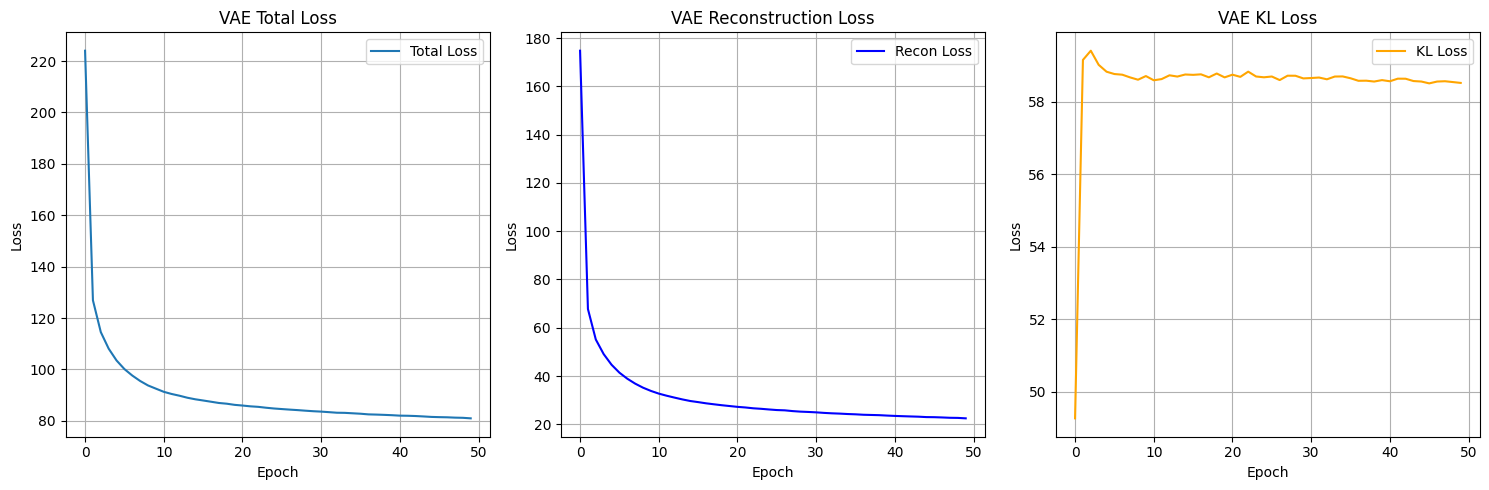

In [7]:
# optimizer_vae = torch.optim.Adam(vae.parameters(), lr=vae_learning_rate)
# scheduler_lr_vae = torch.optim.lr_scheduler.ReduceLROnPlateau(
#     optimizer_vae, mode='min', factor=0.5, patience=5
# )
optimizer_vae = torch.optim.AdamW(
    vae.parameters(), lr=vae_learning_rate, weight_decay=1e-4
)
steps_per_epoch = len(vae_train_loader)
scheduler_lr_vae = torch.optim.lr_scheduler.OneCycleLR(
    optimizer_vae,
    max_lr=vae_learning_rate,
    epochs=vae_num_epochs,
    steps_per_epoch=steps_per_epoch,
    pct_start=0.1,
    anneal_strategy="cos",
    div_factor=10.0,
    final_div_factor=100.0,
)
vae_train_losses = []
vae_train_recon_losses = []
vae_train_kl_losses = []
load_vae = not RETRAIN
vae_path = OUTPUT_DIR / "vae_model.pt"
# Option to save reconstruction frames during training for MP4 creation
save_reconstruction_frames = True
reconstruction_frames_dir = OUTPUT_DIR / "vae_reconstruction_frames"
output_mp4_dir = OUTPUT_DIR / "output_mp4s"
if save_reconstruction_frames:
    reconstruction_frames_dir.mkdir(exist_ok=True)
    output_mp4_dir.mkdir(exist_ok=True)
    # Select sample images at the start (use fixed indices for consistency)
    num_sample_images = 1
    sample_indices = torch.randperm(len(vae_train_dataset))[:num_sample_images].tolist()
    print(
        f"Selected {num_sample_images} sample images for reconstruction tracking (indices: {sample_indices})"
    )
if load_vae and vae_path.exists():
    print(f"Loading VAE from {vae_path}...")
    vae.load_state_dict(torch.load(vae_path, map_location=device))
    vae.eval()
    print("Loaded VAE.")
else:
    if load_vae:
        print(f"VAE checkpoint not found at {vae_path}; training now.")
    else:
        print("Training Elastic Disks VAE.")
    for epoch in range(vae_num_epochs):
        recon_loss, kl_loss, loss = train_vae_epoch(
            vae, vae_train_loader, optimizer_vae, device, beta=vae_beta
        )
        vae_train_losses.append(loss)
        vae_train_recon_losses.append(recon_loss)
        vae_train_kl_losses.append(kl_loss)
        # scheduler_lr_vae.step(loss)
        scheduler_lr_vae.step()
        if (epoch) % 5 == 0:
            print(f"Epoch {epoch}/{vae_num_epochs}")
            print(f"  Total Loss: {loss:.6f}")
            print(f"  Recon Loss: {recon_loss:.6f}")
            print(f"  KL Loss: {kl_loss:.6f}")
            print()
            # Save reconstruction frame every 5 epochs
            if save_reconstruction_frames:
                save_reconstruction_frame(
                    vae,
                    vae_train_dataset,
                    sample_indices,
                    epoch,
                    reconstruction_frames_dir,
                    device,
                )
                print(f"  Saved reconstruction frame for epoch {epoch}")
    # Save VAE
    torch.save(vae.state_dict(), vae_path)
    print(f"VAE saved to {vae_path}")
    # Create MP4 from saved frames
    if save_reconstruction_frames:
        frame_files = sorted(reconstruction_frames_dir.glob("epoch_*.png"))
        if len(frame_files) > 0:
            print(f"\nCreating MP4 from {len(frame_files)} frames...")
            images = []
            for frame_file in frame_files:
                images.append(imageio.imread(frame_file))
            mp4_path = output_mp4_dir / "vae_training_reconstructions.mp4"
            fps = 2  # 2 frames per second (0.5 seconds per frame)
            imageio.mimwrite(str(mp4_path), images, fps=fps, codec="libx264", quality=8)
            print(f"✓ MP4 saved to {mp4_path}")
            display_video(mp4_path)
        else:
            print("No frames found to create MP4")
# Plot training curves
if len(vae_train_losses) > 0:
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    axes[0].plot(vae_train_losses, label="Total Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Loss")
    axes[0].set_title("VAE Total Loss")
    axes[0].legend()
    axes[0].grid(True)
    axes[1].plot(vae_train_recon_losses, label="Recon Loss", color="blue")
    axes[1].set_xlabel("Epoch")
    axes[1].set_ylabel("Loss")
    axes[1].set_title("VAE Reconstruction Loss")
    axes[1].legend()
    axes[1].grid(True)
    axes[2].plot(vae_train_kl_losses, label="KL Loss", color="orange")
    axes[2].set_xlabel("Epoch")
    axes[2].set_ylabel("Loss")
    axes[2].set_title("VAE KL Loss")
    axes[2].legend()
    axes[2].grid(True)
    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / "vae_training_curves.png", dpi=150, bbox_inches="tight")
    plt.show()


## Train Stochastic Interpolant in Latent Space


In [8]:
# Create data loaders for stochastic interpolant training
# These use the frame pairs from train_dataset and test_dataset
si_batch_size = batch_size_for_device(device, si_cfg["batch_size"])
si_num_workers = 0

context_train_dataset = ContextFramePredictionDataset(train_dataset, context_frames=context_frames)
context_test_dataset = ContextFramePredictionDataset(test_dataset, context_frames=context_frames)

elastic_disks_train_loader = DataLoader(
    context_train_dataset,
    batch_size=si_batch_size,
    shuffle=True,
    num_workers=si_num_workers,
    pin_memory=device.type == "cuda",
)

elastic_disks_test_loader = DataLoader(
    context_test_dataset,
    batch_size=si_batch_size,
    shuffle=False,
    num_workers=si_num_workers,
    pin_memory=device.type == "cuda",
)

print(f"Stochastic interpolant data loaders created:")
print(f"  Train: {len(elastic_disks_train_loader)} batches")
print(f"  Test: {len(elastic_disks_test_loader)} batches")


Stochastic interpolant data loaders created:
  Train: 344 batches
  Test: 86 batches


VAE loaded for stochastic interpolant training.
Stochastic interpolant checkpoint not found at /content/generative-video-forecasting/outputs/train_elastic_disks_latent_stochastic_interpolant/latent_stochastic_interpolant_elastic_disks_model.pt; training now.


Evaluating Stochastic Interpolant: 100%|██████████| 86/86 [00:02<00:00, 30.02it/s]


Epoch 1/100 - Saved best model (val_loss: 1.376677)


Evaluating Stochastic Interpolant: 100%|██████████| 86/86 [00:02<00:00, 30.98it/s]


Epoch 2/100 - Saved best model (val_loss: 0.990907)


...

Epoch 97/100 - Saved best model (val_loss: 0.128844)


Evaluating Stochastic Interpolant: 100%|██████████| 86/86 [00:02<00:00, 30.89it/s]


Epoch 99/100 - Saved best model (val_loss: 0.128776)


Evaluating Stochastic Interpolant: 100%|██████████| 86/86 [00:02<00:00, 30.52it/s]


Epoch 100/100
  Train Loss: 0.129929
  Val Loss: 0.129141

Training completed!
Best validation loss: 0.128776


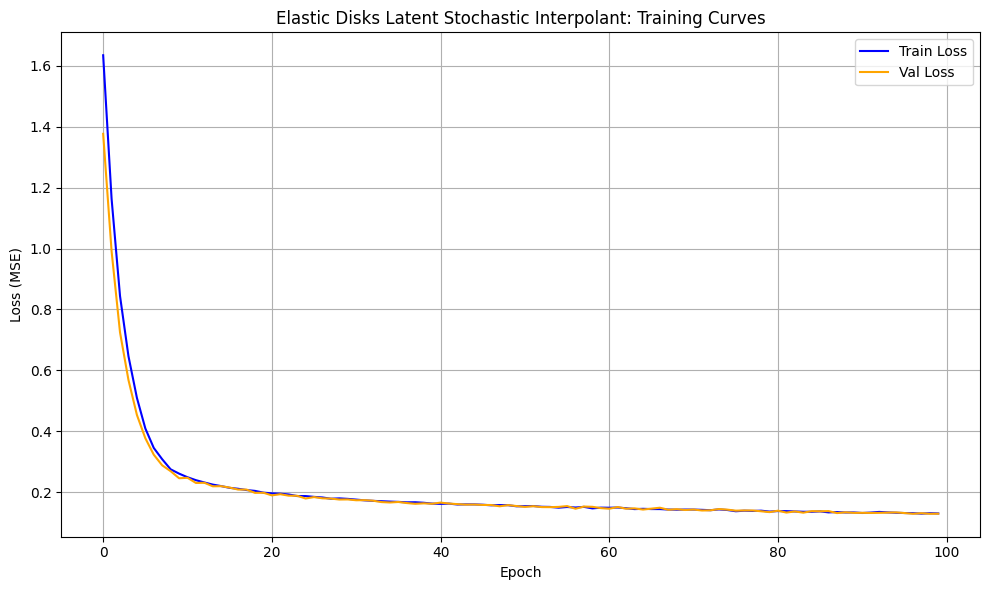

In [9]:
# Train Elastic Disks stochastic interpolant model
si_learning_rate = si_cfg["learning_rate"]
si_num_epochs = si_cfg["num_epochs"]
# Initialize stochastic interpolant utils
si_utils = StochasticInterpolantUtils(
    sigma_coef=si_cfg["sigma_coef"],
    beta_fn=si_cfg["beta_fn"],
)
optimizer_si = torch.optim.Adam(
    si_model.parameters(), lr=si_learning_rate
)
scheduler_lr_si = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer_si, mode="min", factor=0.5, patience=10
)
train_losses = []
val_losses = []
best_val_loss = float("inf")
load_si = not RETRAIN
si_path = OUTPUT_DIR / "latent_stochastic_interpolant_elastic_disks_model.pt"
# Make sure VAE is loaded
if not vae_path.exists():
    print("Missing VAE checkpoint; run the VAE training cell first.")
else:
    vae.load_state_dict(torch.load(vae_path, map_location=device))
    vae.eval()
    print("VAE loaded for stochastic interpolant training.")
if load_si and si_path.exists():
    print(f"Loading stochastic interpolant model from {si_path}...")
    si_model.load_state_dict(torch.load(si_path, map_location=device))
    si_model.eval()
    print("Loaded stochastic interpolant model.")
else:
    if load_si:
        print(f"Stochastic interpolant checkpoint not found at {si_path}; training now.")
    else:
        print("Training Elastic Disks latent stochastic interpolant model.")
    for epoch in range(si_num_epochs):
        # Train
        train_loss = train_stochastic_interpolant_epoch(
            si_model,
            vae,
            elastic_disks_train_loader,
            si_utils,
            optimizer_si,
            device,
        )
        # Evaluate on test set
        val_loss = evaluate_stochastic_interpolant(
            si_model, vae, elastic_disks_test_loader, si_utils, device
        )
        # Store history
        train_losses.append(train_loss)
        val_losses.append(val_loss)
        # Update learning rate scheduler
        scheduler_lr_si.step(val_loss)
        # Save best model
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(si_model.state_dict(), si_path)
            print(
                f"Epoch {epoch + 1}/{si_num_epochs} - Saved best model (val_loss: {val_loss:.6f})"
            )
        if (epoch + 1) % 5 == 0:
            print(f"Epoch {epoch + 1}/{si_num_epochs}")
            print(f"  Train Loss: {train_loss:.6f}")
            print(f"  Val Loss: {val_loss:.6f}")
            print()
    print("Training completed!")
    print(f"Best validation loss: {best_val_loss:.6f}")
# Plot training curves
if len(train_losses) > 0:
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    ax.plot(train_losses, label="Train Loss", color="blue")
    ax.plot(val_losses, label="Val Loss", color="orange")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Loss (MSE)")
    ax.set_title("Elastic Disks Latent Stochastic Interpolant: Training Curves")
    ax.legend()
    ax.grid(True)
    plt.tight_layout()
    plt.savefig(
        OUTPUT_DIR / "latent_stochastic_interpolant_training_curves.png",
        dpi=150,
        bbox_inches="tight",
    )
    plt.show()
else:
    print("No training history available. Train the model first.")


## Evaluation, Visualizations, and Rollouts

Load saved checkpoints, create prediction figures, and generate rollout movies.


Loading trained models...
Loaded VAE.
Loaded stochastic interpolant model.

Generating visualizations...


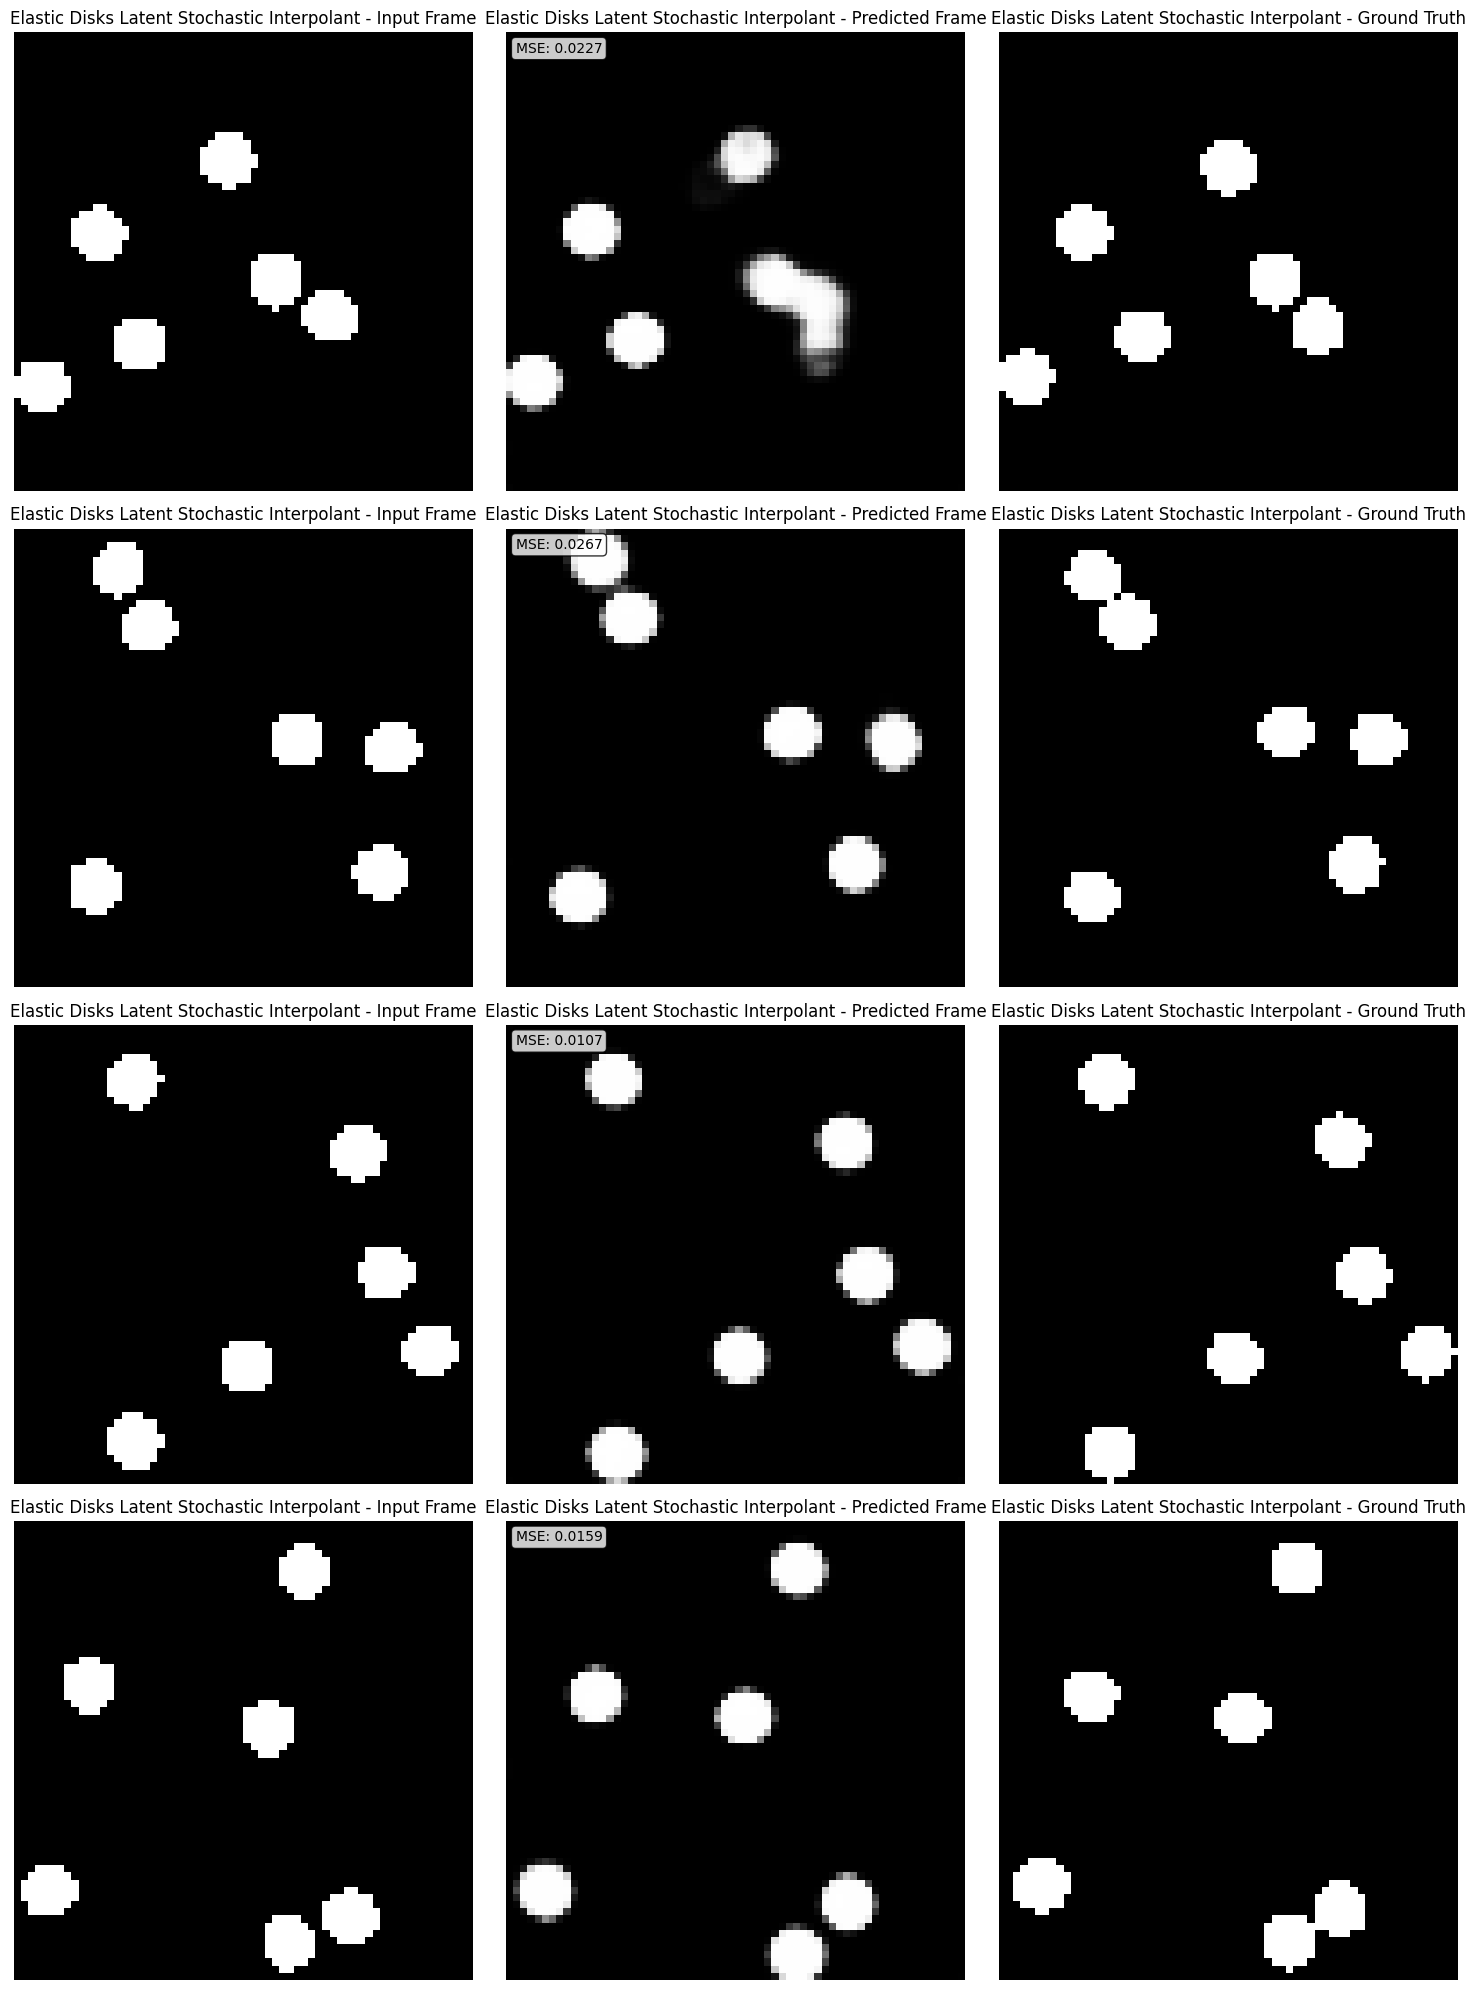

In [10]:
# Load trained models
vae_path = OUTPUT_DIR / "vae_model.pt"
si_path = OUTPUT_DIR / "latent_stochastic_interpolant_elastic_disks_model.pt"
if vae_path.exists() and si_path.exists():
    print(f"Loading trained models...")
    vae.load_state_dict(torch.load(vae_path, map_location=device))
    vae.eval()
    print("Loaded VAE.")
    si_model.load_state_dict(torch.load(si_path, map_location=device))
    si_model.eval()
    print("Loaded stochastic interpolant model.")
    # Visualize predictions
    print("\nGenerating visualizations...")
    visualize_predictions(
        si_model,
        vae,
        context_test_dataset,
        si_utils,
        num_samples=4,
        device=device,
        title_prefix="Elastic Disks Latent Stochastic Interpolant - ",
        num_inference_steps=si_cfg["num_inference_steps"],
    )
else:
    print("Missing model files; run the training cells first.")
    if not vae_path.exists():
        print(f"  Missing: {vae_path}")
    if not si_path.exists():
        print(f"  Missing: {si_path}")


In [11]:
# Generate rollout movie
if vae_path.exists() and si_path.exists():
    # Use first sequence from test dataset for rollout
    test_sequence_idx = 0
    test_sequence = test_dataset.sequences[test_sequence_idx]  # [T, C, H, W]
    print(
        f"Using test sequence {test_sequence_idx} with {len(test_sequence)} frames..."
    )
    print(f"Generating rollout movie for test sequence {test_sequence_idx}...")
    rollout_path = generate_rollout_movie(
        drift_model=si_model,
        vae=vae,
        si_utils=si_utils,
        test_dataset=test_dataset,
        sequence=test_sequence,
        dataset_type="elastic_disks",
        frame_separation=frame_separation,
        context_frames=context_frames,
        start_frame=0,
        num_predictions=20,
        device=device,
        fps=10,
        output_dir=str(OUTPUT_DIR / "output_mp4s"),
        num_inference_steps=si_cfg["num_inference_steps"],
        use_ddim=True,
    )
    print(f"Rollout movie saved to: {rollout_path}")
    display_video(rollout_path)
else:
    print("Missing model files; run the training cells first.")


Using test sequence 0 with 32 frames...
Generating rollout movie for test sequence 0...
Using sequence with shape (32, 1, 64, 64)...
  Sequence shape: 32 frames, 1 channels, 64x64
Generating 20 prediction steps...
  Starting from frame 0


Generating predictions: 100%|██████████| 20/20 [00:10<00:00,  1.95it/s]

Creating video frames...
Saving video to /content/generative-video-forecasting/outputs/train_elastic_disks_latent_stochastic_interpolant/output_mp4s/elastic_disks_sequence_0_latent_stochastic_interpolant_rollout.mp4...
Saved video to /content/generative-video-forecasting/outputs/train_elastic_disks_latent_stochastic_interpolant/output_mp4s/elastic_disks_sequence_0_latent_stochastic_interpolant_rollout.mp4
Rollout movie saved to: /content/generative-video-forecasting/outputs/train_elastic_disks_latent_stochastic_interpolant/output_mp4s/elastic_disks_sequence_0_latent_stochastic_interpolant_rollout.mp4
